# Исследование стартапов

- Автор: Захаров Максим 
- Дата: 19.01.2025

##  Введение

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».

### Цели и задачи проекта

**Цель:** Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Проанализировать группы компаний по срокам финансирования:выделить группы компаний по срокам финансирования и по количеству и объему инвестиций.
4. Классифицировать рынок на массовые, средние и нишевые сегменты.
5. Определить типичные и аномальные значения объемов финансирования,исключить выбросы и ограничить период исследования.
6. Сравнить популярность и объемы разных видов финансирования
7. Проанализировать динамику раундов и объемов инвестиций по годам, а также изменения в массовых сегментах рынка.
8. Рассчитать долю возврата средств для разных типов финансирования и оценить ее устойчивость.
9. Сформулировать выводы по проведенному анализу.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Загружаем все необходимые библиотеки:
import pandas as pd
# Загружим библиотеки для визуализации данных:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем данных из датасета cb_investments.zip
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
# Загружаем данные из 2 датасета cb_returns :
df_returns=pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")


Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

Познакомимся с данными датасета `cb_investments` выведем первые строчки методом `head()`,а информацию о датафрейме `info()`

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
df.head(6)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Выведите информацию, которая необходима для принятия решений о предобработке.

In [5]:
# Находим критические пропуски:
df.isnull().mean().sort_values(ascending=False).head(10)*100

state_code         44.448742
mid_funding_at     44.214830
participants       43.874093
founded_month      29.122923
founded_quarter    29.122923
founded_at         28.990312
founded_year       28.990312
city               20.208494
country_code       18.655837
region             18.655837
dtype: float64

Датафрейм `cb_investments` содержит 40 столбцов и 54293 строк,которые содержат информацию о компаниях и состоявшемся финансировании.

После первичного анализа можно сделать следующие выводы:

    - В названии столбцов в основном используют вид snake_case,но потребуется убрать лишние пробелы в начале названий market и funding_total_usd.
    - Типы данных во всех остальных столбцах присвоены корректно,кроме:
        funding_total_usd - общий объем инвестиций в долларах. Имеет тип object,но должен быть числом int64.
        founded_year - год основания,год - целое число,поэтому необходимо изменить тип данных с float64 на int64.
        founded_at, first_funding_at, mid_funding_at, last_funding_at - содержат информацию о датах. Нужно изменить тип данных с object  на datetime64.

В данных встречаются пропуски. 

Критическими являются: state_code - 44.4% ,mid_funding_at - 44.2% , participants - 43.8% - геоданные и даты финансрования.
    Даты основания : founded_month, founded_quarter, founded_at, founded_year- 29.0% 
     География: city,country_code,region - 18-20%
    
    
    
    
    
    

Позакомимся с данными второго датасета `df_returns` выведем первые строчки методом `head()`,а информацию о датафрейме `info()`

In [6]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
# Проверка критических пропусоков
df_returns.isnull().mean().sort_values(ascending=False).head(10)

year                   0.0
seed                   0.0
venture                0.0
equity_crowdfunding    0.0
undisclosed            0.0
convertible_note       0.0
debt_financing         0.0
angel                  0.0
grant                  0.0
private_equity         0.0
dtype: float64

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет `df_returns` содержит 14 столбцов и 15 строк, в которых представлена информация об объемах возвратов по годам и типам финансирования в миллионах долларах.

- Названия столбцов уже приведены к одному виду snake case и не требуют изменений
- Пропуски отсутствуют
- Типы данных корректны 

Данные в датасете готовы к анализу без предобработки.


### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [9]:
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

В датасете `cb_investments` есть два столбца,в которых найдены пробелы: `market` и  `funding_total_usd`

In [10]:
df_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Датасет `cb_returns` готов к дальнейшему анализу и не требует изменений поскольку:

    - в столбцах нет лишних пробелов
    - все названия приведены к единому стилю snake_case
    - понятно отражено содержимое

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [11]:
# 1 Убираем пробелы в названиях столбцов
df.columns = df.columns.str.strip()

# 2  Убираем запятые и прочерки, преобразуем в число
df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'].str.replace(',', ''), 
    errors='coerce'
)

# 3 Проверяем
print(f"Тип: {df['funding_total_usd'].dtype}")
print(f"Пропуски: {df['funding_total_usd'].isnull().sum()}")
print(f"Первые значения: {df['funding_total_usd'].head(3).tolist()}")

Тип: float64
Пропуски: 13387
Первые значения: [90000000.0, 2000000.0, 9000000.0]


In [12]:
# Преобразуем в строку, убираем запятые, обратно в число
df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'].astype(str).str.replace(',', ''), 
    errors='coerce'
)
print(f"Тип: {df['funding_total_usd'].dtype}")

Тип: float64


`funding_total_usd` уже имеет тип `float64`,выделение разрядов убрано  в предудыщих шагах обработки

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [13]:
# 1 Преобразуем даты в datetime
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['mid_funding_at'] = pd.to_datetime(df['mid_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

# 2 Преобразуем год в целое число 
df['founded_year'] = df['founded_year'].astype('Int64')

# 3 Проверяем 
print("Типы данных после преобразования:")
print(df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_year']].dtypes)

Типы данных после преобразования:
founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
founded_year                 Int64
dtype: object


В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [14]:
# Делаем столбец year индексом датасета
df_returns.set_index('year', inplace=True)

# Проверяем результат
print("Индекс есть:")
print(df_returns.index)
print(f"\nПервые строки:")
print(df_returns.head())

Индекс есть:
Int64Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
            2011, 2012, 2013, 2014],
           dtype='int64', name='year')

Первые строки:
       seed  venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                       
2000  16.70    55.40                  0.0        78.21              0.00   
2001   2.88    23.49                  0.0        21.50              0.01   
2002   6.59   209.42                  0.0        25.77              0.02   
2003   7.74   233.86                  0.0         9.40              0.01   
2004   9.93   555.90                  0.0        33.19              0.01   

      debt_financing  angel  grant  private_equity  post_ipo_equity  \
year                                                                  
2000            8.66   6.43    0.0            0.00             0.94   
2001            4.49   1.18    0.0            0.00             0.46   


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [15]:
# 1 Основные столбцы заполним 'unknown'
cols_unknown = ['name', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
df[cols_unknown] = df[cols_unknown].fillna('unknown')

# 2 homepage_url заполним 'no_website'
df['homepage_url'] = df['homepage_url'].fillna('no_website')

# 3 category_list очистим от |
df['category_list'] = df['category_list'].fillna('not_specified').str.strip('|')

print("Тестовые данные обработаны")

Тестовые данные обработаны


Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [16]:
# Находим дубликаты в funding_total_usd
duplicates = df['funding_total_usd'].duplicated()
print(f"Дубликатов в funding_total_usd: {duplicates.sum()}")

# выводим дублирующиеся значения
if duplicates.sum() > 0:
    print("Примеры дублированных сумм:")
    print(df['funding_total_usd'][duplicates].head(5))

Дубликатов в funding_total_usd: 39677
Примеры дублированных сумм:
15           NaN
18     2000000.0
19           NaN
21     2000000.0
23    90000000.0
Name: funding_total_usd, dtype: float64


In [17]:
# Пропуски в funding_total_usd. Мы удаляем те строчки, где funding_total_usd=Nan
df=df.dropna(subset=['funding_total_usd'])

Удалили строки с пропусками в `funding_total_usd`, так как без суммы финансирования анализ невозможен. Дубликаты сумм оставили, поскольку разные компании могут получать одинаковые объёмы финансирования."

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [18]:
# Заполняем пропуски в mid_funding_at
df['mid_funding_at'] = df['mid_funding_at'].fillna(
    df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
)

# Проверяем
print(f"Осталось пропусков: {df['mid_funding_at'].isna().sum()}")

Осталось пропусков: 1


In [19]:
# Найдём оставшийся пропуск
remaining_na = df[df['mid_funding_at'].isna()]
print("Строка с пропуском mid_funding_at:")
print(remaining_na[['name', 'first_funding_at', 'mid_funding_at', 'last_funding_at']])

Строка с пропуском mid_funding_at:
         name first_funding_at mid_funding_at last_funding_at
33041  Nubank              NaT            NaT      2014-09-25


In [20]:
# Заполним пропуск значением last_funding_at
df['mid_funding_at'] = df['mid_funding_at'].fillna(df['last_funding_at'])
print("Заполнили последним финансированием")

Заполнили последним финансированием


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [21]:
# Оценка потерь
initial = 54294  
current = len(df)
lost = initial - current
lost_percent = (lost / initial) * 100

print(f"Отброшено: {lost} строк ({lost_percent:.1f}%)")
print(f"Осталось: {current} строк ({(100-lost_percent):.1f}% данных)")

Отброшено: 13387 строк (24.7%)
Осталось: 40907 строк (75.3% данных)


Проанализировав данные датасетов,можно сделать следущие выводы:

В датасете `cb_investments` потеряно 24.7% данных, остальные 75.3% - данных сохранено.
- Для анализа есть 40907 компаний с финансированием
- Больше нет пропусков в ключевых полях `funding_total_usd`, даты.

Данных более чем достаточно для дальнейшего анализа.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [22]:
# 2.1 Разделим компании на 3 группы:
# Создаем группы финансировани. По умолчанию ставим значение more_than_year
df['funding_group'] = 'more_than_year'

# Компании с одним раундом
df.loc[df['funding_rounds'] == 1, 'funding_group'] = 'single'

# Компании с несколькими раундами и разницей до года
multi_round = df['funding_rounds'] > 1
days_diff = (df['last_funding_at'] - df['first_funding_at']).dt.days
df.loc[multi_round & (days_diff <= 365), 'funding_group'] = 'up_to_year'

print(df['funding_group'].value_counts())

single            24113
more_than_year    12293
up_to_year         4501
Name: funding_group, dtype: int64


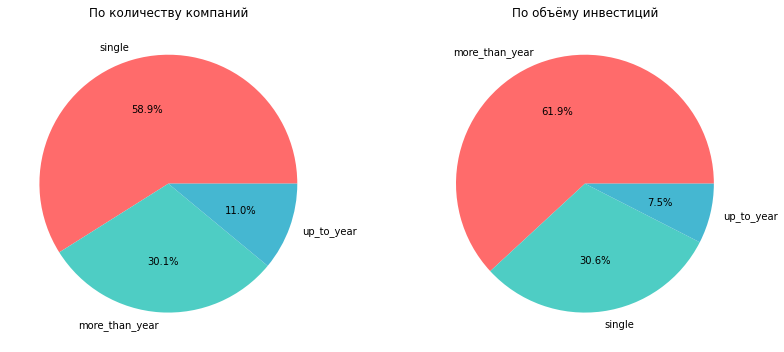

In [23]:
# Визуализируем данные:

# Данные для визуализации:
counts=df['funding_group'].value_counts()
investments=df.groupby('funding_group')['funding_total_usd'].sum()

# Графики
fif,axes=plt.subplots(1,2,figsize=(12,5))

# По количеству:
axes[0].pie(counts,labels=counts.index,autopct='%1.1f%%',      
colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('По количеству компаний')

# По объему:
axes[1].pie(investments,labels=investments.index, autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('По объёму инвестиций')

plt.tight_layout()
plt.show()

Компании с финансированием более года (30%) компаний привлекают 62% всех средств - в два раза больше своей доли.
Компании с единичным финансированием (59%) получают всего 31% инвестиций - почти в раза ниже своей доли.
Компании с финансированием до года (11%) привлекают 7.5% - немного меньше своей доли.

Инвесторы готовы вкладываться в ту компанию,которая показывает долгосрочную перспективу и историю нескольких раундов финансирования.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Количество сегментов по категориям
Массовые (>120): 54
Средние (35-120)): 81
Нишевые (<35)):714


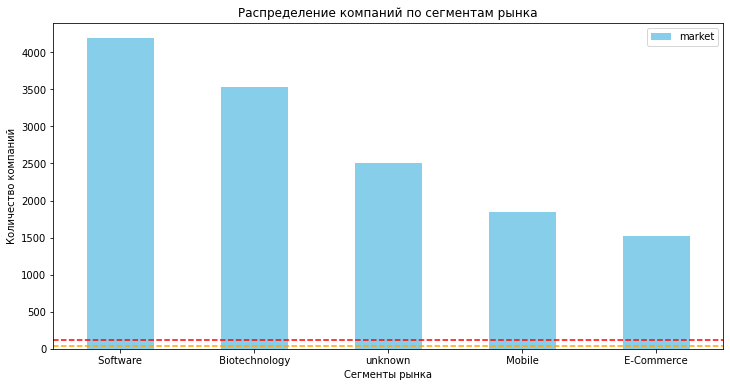

In [24]:
# 1 Считаем категории в каждом сегменте

segments_counts=df['market'].value_counts()

# 2 Разделим на категории:

massive=segments_counts[segments_counts>120]
medium=segments_counts[(segments_counts >=35) & (segments_counts <= 120)]
niche=segments_counts[segments_counts < 35]

# 3 Выводим результаты:

print("Количество сегментов по категориям")
print(f"Массовые (>120): {len(massive)}")
print(f"Средние (35-120)): {len(medium)}")
print(f"Нишевые (<35)):{len(niche)}")

# 4 Рисуем график:

segments_counts.sort_values(ascending=False).head().plot(
kind='bar',
title='Распределение компаний по сегментам рынка',
legend=True,
ylabel='Количество компаний',
xlabel='Сегменты рынка',
rot=0,
color='skyblue',
figsize=(12,6)
)
plt.axhline(y=120, color='red', linestyle='--')
plt.axhline(y=35, color='orange', linestyle='--')
plt.show()

`Software` и `Biotechnology` - явные лидеры в массовых сегментах.


Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [25]:
# 1 Создадим словарь
replace_dict={}

# 2  Массовые сегменты оставим как есть
for segment in massive.index:
    replace_dict[segment]=segment
# 3 Нишевые заменим на `niche`

for segment in niche.index:
    replace_dict[segment]='niche'
    
# 4 Средние заменим на `mid`
for segment in medium.index:
    replace_dict[segment]='mid'
    
# 5 Производим замену значений:
df['market']=df['market'].map(replace_dict)

# Проверяем:
print("Новое распределение:")
print(df['market'].value_counts().head())
    

Новое распределение:
mid                5069
 Software          4190
 Biotechnology     3531
unknown            2503
niche              2494
Name: market, dtype: int64


Рынок высоко сконцентрирован: всего 3 массовых сегмента(Software,Biotechnology,unknown) доминируют. Основными рынками являются Software и Biotechnology 

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

Типично: $350,000-$10,000,000
Выбросы: >$24,475,000


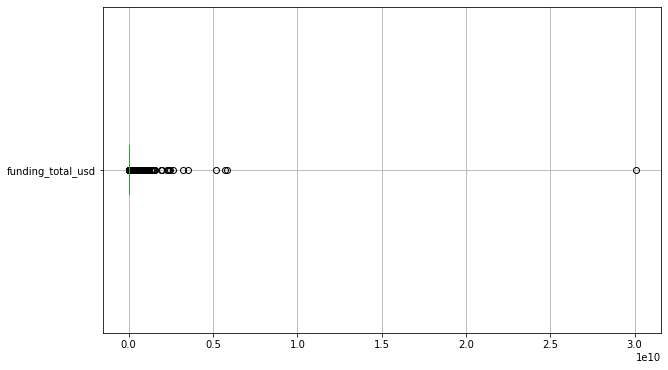

In [26]:
df[['funding_total_usd']].boxplot(vert=False,grid=True,figsize=(10,6))

# Определим границы выбросов:
Q1=df['funding_total_usd'].quantile(0.25)
Q3=df['funding_total_usd'].quantile(0.75)
IQR=Q3-Q1

# Проверяем
print(f"Типично: ${Q1:,.0F}-${Q3:,.0F}")
print(f"Выбросы: >${Q3+1.5*IQR:,.0f}")

Типичный размер финансирования находится в диапозоне $350тыс - $10млн, что говорит нам о среднем уровне инвестиций.

Наблюдаются значительные выбросы - $24,5 млн  и  $10 млн, что в сотни раз превышает верхнюю границу типичного диапозона.

Данные показали крайнюю неравномернсть в распределении инвестиций.Основная часть проектов финансируется умеренно,тогда как единичные случаи привлекают колоссальные суммы.


Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [27]:
# 1 Создаем группу:
df['group']=df['market'].map(lambda x:'Нишевые'if x in ['Mobile'] else 'Средние')

# 1 Отмечаем компании с аномальным объемом финансирования:
df['is_anomaly'] = False

# 2. Применяем IQR отдельно для каждой группы
for group in ['Нишевые', 'Средние']:
    # Берем данные только этой группы
    group_data = df[df['group'] == group]  # ← исправлено
    funding = group_data['funding_total_usd']
    
    # Считаем квартили и IQR
    Q1 = funding.quantile(0.25)
    Q3 = funding.quantile(0.75)
    IQR = Q3 - Q1
    
    # Находим выбросы (аномалии)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Помечаем аномальные компании
    anomalies = group_data[
        (funding < lower_bound) | 
        (funding > upper_bound)
    ]
    
    df.loc[anomalies.index, 'is_anomaly'] = True

# 3. Находим топ сегментов по доле аномалий
result = []
for segment in df['market'].unique():  
    # Данные только этого сегмента
    segment_data = df[df['market'] == segment]  
    
    # Сколько всего компаний в сегменте
    total = len(segment_data)
    
    # Сколько аномальных
    anomalies = segment_data['is_anomaly'].sum()
    
    # Доля аномалий в процентах
    percent = (anomalies / total * 100) if total > 0 else 0
    
    result.append([segment, total, anomalies, round(percent, 2)])

# Создаем таблицу и сортируем по доле аномалий
result_df = pd.DataFrame(result, 
                        columns=['Сегмент', 'Всего компаний', 'Аномалий', 'Доля аномалий%'])

result_df = result_df.sort_values('Доля аномалий%', ascending=False)

# Выводим топ
print("Топ сегментов с аномальным финансированием:")
print(result_df.head(10).to_string(index=False))

Топ сегментов с аномальным финансированием:
              Сегмент  Всего компаний  Аномалий  Доля аномалий%
      Semiconductors              473       153           32.35
    Clean Technology             1094       300           27.42
         Health Care             1128       308           27.30
         Web Hosting              400       108           27.00
          Technology              229        58           25.33
       Biotechnology             3531       805           22.80
             Software             137        27           19.71
            Security              491        79           16.09
     Cloud Computing              131        21           16.03
 Enterprise Software             1190       188           15.80


<div class="alert alert-info"> <b>Комментарий студента:</b> 
    
`Semiconductors`(32%) и `Clean Technology`(27%) - лидеры по аномальным инвестициям. В этих отраслях компания получает нетипично большие или малые финансирования.

`Health Care`(27%) и `Biotechnology`(23%) также показывают высокую доля аномалий.Эти сегменты с высоким риском и потенциалом больших прорывов.

Остальные сегменты более стабильны, но такде имеют 15-20% аномалий.</div>

Доля компаний с аномальным финансированием составляет 12-13%.Различия между сегментами минимальны, особых лидеров нет.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [28]:
# 1 Проверяем данные за 2014
print(f"2014: {(pd.to_datetime(df['last_funding_at']).dt.year == 2014).sum()} записей")

2014: 11915 записей


In [29]:
print("2014 год:")
print(f"Записей: {(pd.to_datetime(df['last_funding_at']).dt.year == 2014).sum()}")
print(f"Месяцев: {df[pd.to_datetime(df['last_funding_at']).dt.year == 2014]['last_funding_at'].dt.month.nunique()}")
print(f"Все 12 месяцев: {df[pd.to_datetime(df['last_funding_at']).dt.year == 2014]['last_funding_at'].dt.month.nunique() == 12}")

2014 год:
Записей: 11915
Месяцев: 12
Все 12 месяцев: True


В данных за 2014 год 11915 записей. Этого достаточно для анализа

In [30]:
# 2 Исключаем аномальные компании
print(f"До удаления аномалий:")
print(f"Всего компаний: {len(df)}")

# Считаем кол-во аномальных:
anomalies_count=df['is_anomaly'].sum()
print(f"Аномальных компаний: {anomalies_count}")

# Исключаем аномальные компании
df=df[~df['is_anomaly']].copy()

print("\nПосле удаления аномалий:")
print(f"Осталось компаний: {len(df)}")
print(f"Удалили: {anomalies_count} компаний")

До удаления аномалий:
Всего компаний: 40907
Аномальных компаний: 5232

После удаления аномалий:
Осталось компаний: 35675
Удалили: 5232 компаний


In [31]:
# 3 Оставляем в датасете данные о компаниях в которых было зафиксировано 50 или более раундов финансирования.
df['year'] = pd.to_datetime(df['mid_funding_at']).dt.year

# Считаем записи по годам
year_counts = df['year'].value_counts()

# Годы 50+ записей
good_years = year_counts[year_counts >= 50].index  # было good_year, должно быть good_years

# Фильтруем данные
df = df[df['year'].isin(good_years)]  # здесь используем good_years
print(f"Осталось {len(df)} компаний")



Осталось 35553 компаний


Проверили данные за 2014 - они оказались полными,удалили аномальные значения, оставили только компании из городов с 50+ раундов.

Осталось 35441 компания.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

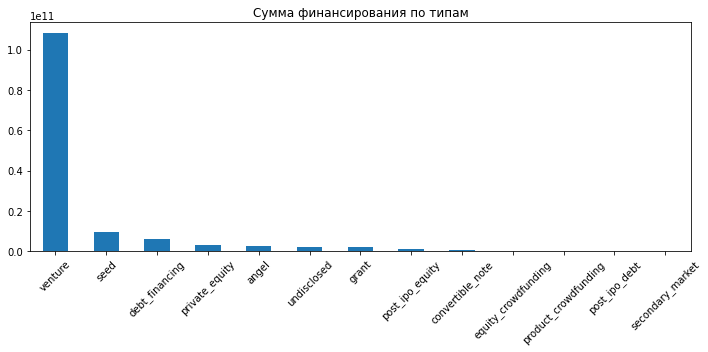

In [32]:
# 1 Построим график, который покажет какие типы финансирования привлекли больше всего денег.
# Типы финансирования. Создаем переменную types чтобы собрать все названия в один список. 
types=['seed','venture','equity_crowdfunding','undisclosed','convertible_note','debt_financing','angel','grant',
      'private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']
# Посчитаем сумму по кадому:
totals=df[types].sum().sort_values(ascending=False)

#Рисуем график:
totals.plot(kind='bar', figsize=(10, 5))
plt.title('Сумма финансирования по типам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

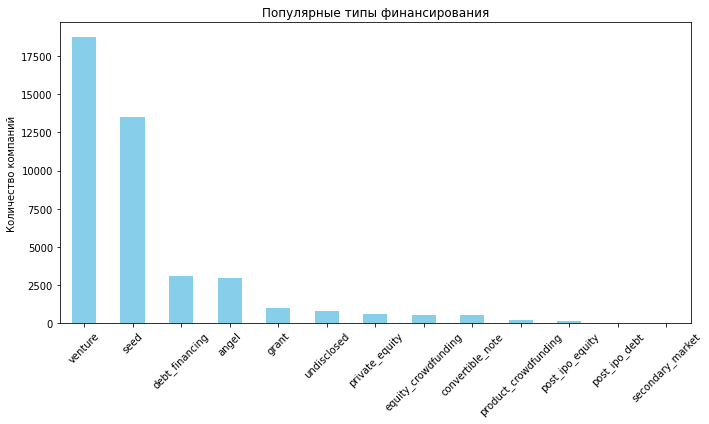

In [33]:
# Создаем второй график по популярности типов финансирования
popularity = (df[types] > 0).sum().sort_values(ascending=False)

# Создаем график
popularity.plot(
    kind='bar',
    title='Популярные типы финансирования',
    color='skyblue',
    figsize=(10, 6)
)
plt.xticks(rotation=45)
plt.ylabel('Количество компаний')
plt.tight_layout()
plt.show()

Самым популярным и крупным по объему является тип `venture`, он используется чаще всего и в него вкладывают больше денег.

`seed`, `angel`, `grant`популярны среди компаний, однако привлекают гораздо меньшие суммы. Являются стартовым финансированием многих проектов.

`debt_financing` и  `private_equity` используются реже, но суммы в них значительно выше. 

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

df_returns - дополнительный(2-ой) датасет

In [34]:
# Загружаем данные
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

# Считаем сумму каждой колонки
for col in df_returns.columns:
    total = df_returns[col].sum()
    print(f"{col}: {total:.0f}")

year: 30105
seed: 2382
venture: 40579
equity_crowdfunding: 4
undisclosed: 731
convertible_note: 35
debt_financing: 4735
angel: 1509
grant: 0
private_equity: 3587
post_ipo_equity: 1105
post_ipo_debt: 91
secondary_market: 5
product_crowdfunding: 2


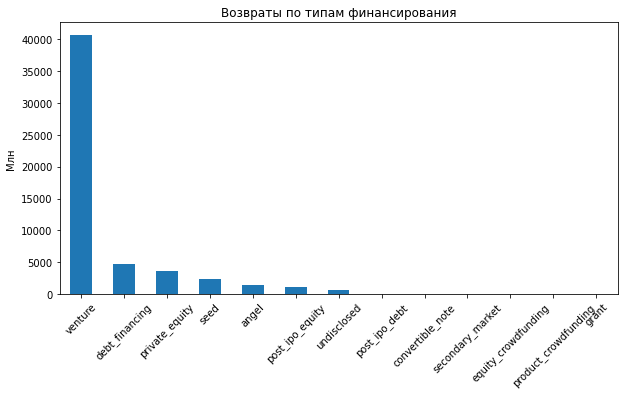

Топ-3:
venture           40578.62
debt_financing     4734.85
private_equity     3587.33
dtype: float64


In [35]:
return_sum = df_returns.drop('year', axis=1).sum().sort_values(ascending=False)

# График
return_sum.plot(kind='bar', figsize=(10, 5))
plt.title('Возвраты по типам финансирования')
plt.ylabel('Млн ')
plt.xticks(rotation=45)
plt.show()

print("Топ-3:")
print(return_sum.head(3))

Вунчурные инвестиции предоставляют 85% всех возратов.Это значит,что вунчурные инвестиции - самый надежный способ зарабатывать.
Долговое финансирование и сумма инвестиций в виде прямых (частных) вложений вместе дают еще 17%.Безопасные инвестиции в состоявшие компании.
Все остальные типы в сумме дают меньше 2% возвратов. Большинство стартапов не возвращает деньги инвесторам.


## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [36]:
# 1 Рассчитаем для каждой компании средний объем одного раунда финансирования:
df['avg_round']=df['funding_total_usd'] / df['funding_rounds']

# Проверяем
print("Средний объем раунда")
print("f Пример для первых 5 компаний:")
print(df[['name','funding_total_usd','funding_rounds','avg_round']].head())

Средний объем раунда
f Пример для первых 5 компаний:
                              name  funding_total_usd  funding_rounds  \
1      University of New Brunswick          2000000.0             1.0   
2                           DuPont          9000000.0             1.0   
3           University of Michigan          7700000.0             3.0   
4  Case Western Reserve University           540000.0             1.0   
5                Xavier University         19000000.0             1.0   

      avg_round  
1  2.000000e+06  
2  9.000000e+06  
3  2.566667e+06  
4  5.400000e+05  
5  1.900000e+07  


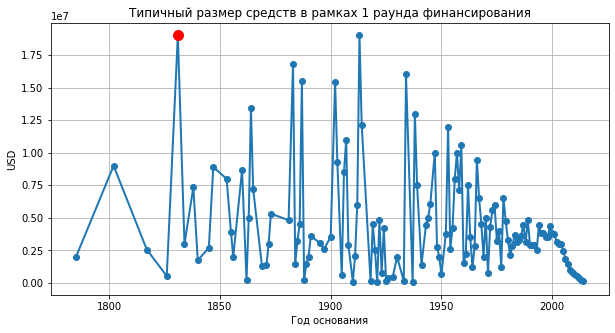

Максимальный размер средств был в 1831 году:$19,000,000


In [37]:
# 2 График типичного размера раунда

# Медиана по годам
med_round = df.groupby('founded_year')['avg_round'].median()

# Найдем год и максимальный размер средств
max_year=med_round.idxmax()

max_value=med_round.max()


# Строим график:
# Красной точкой выделим максимальный размер средств
plt.scatter(max_year,max_value,color='red',s=100,zorder=5,label=f'Максимум:{max_year}год')


med_round.plot(figsize=(10,5), marker='o', linewidth=2)
plt.title('Типичный размер средств в рамках 1 раунда финансирования')
plt.xlabel('Год основания')
plt.ylabel('USD')
plt.grid(True)
plt.show()

print(f"Максимальный размер средств был в {max_year} году:${max_value:,.0f}")

Максимальный размер средств был в 1831 году:$19,000,000

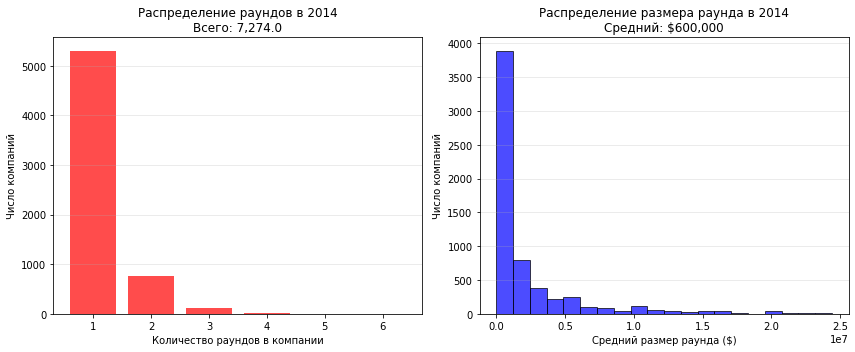

In [38]:
if 2014 in df['year'].unique():
    # Данные за 2014
    data_2014 = df[df['year'] == 2014]
    
    # Создаем 2 графика
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1 Количество раундов (
    rounds_counts = data_2014['funding_rounds'].value_counts().sort_index()
    ax1.bar(rounds_counts.index, rounds_counts.values, color='red', alpha=0.7)
    ax1.set_title(f'Распределение раундов в 2014\nВсего: {data_2014["funding_rounds"].sum():,}')
    ax1.set_xlabel('Количество раундов в компании')
    ax1.set_ylabel('Число компаний')
    ax1.grid(axis='y', alpha=0.3)
    
    # 2 Размер средств 
    ax2.hist(data_2014['avg_round'].dropna(), bins=20, color='blue', alpha=0.7, edgecolor='black')
    ax2.set_title(f'Распределение размера раунда в 2014\nСредний: ${data_2014["avg_round"].median():,.0f}')
    ax2.set_xlabel('Средний размер раунда ($)')
    ax2.set_ylabel('Число компаний')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("2014 год не найден")

В 2014 году наблюдается следующая тенденция:
- Много сделок: 6773 раундов
- Средний размер раунда 650 тыс

1831 был максимальный размер средств в рамках одного раунда.

В 2014 году наблюдается следующая тенденция:
- Много сделок: 6773 раундов
- Средний размер раунда 650 тыс

Пик размера раундов в 1831, в 2014 - много сделок,но среднего размера

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [39]:
# Группируем данные по рынку/отрасли компании и году основания. Суммируем финансирование для каждой группы.
finans = df.groupby(['market', 'founded_year'])['funding_total_usd'].sum().unstack()

if 2013 in finans.columns and 2014 in finans.columns:
    # Только растущие сегменты
    growing = finans[finans[2014] > finans[2013]]
    
    # Создаем сводную  таблицу
    table_data = []
    for market in growing.index:
        table_data.append({
            'Сегмент': market,
            '2013': growing.loc[market, 2013],
            '2014': growing.loc[market, 2014],
            'Рост': f"{((growing.loc[market, 2014]/growing.loc[market, 2013]-1)*100):.1f}%"
        })
    
    # Выводим
    result_df = pd.DataFrame(table_data)
    print(result_df.sort_values('Рост', ascending=False).to_string(index=False))

           Сегмент       2013       2014   Рост
          Medical   4180100.0  8220780.0  96.7%
 Public Relations    426372.0   460000.0   7.9%
      Web Hosting   1082462.0  6319252.0 483.8%
    Manufacturing  10531434.0 14622900.0  38.9%
          Software  4500476.0 10065000.0 123.6%


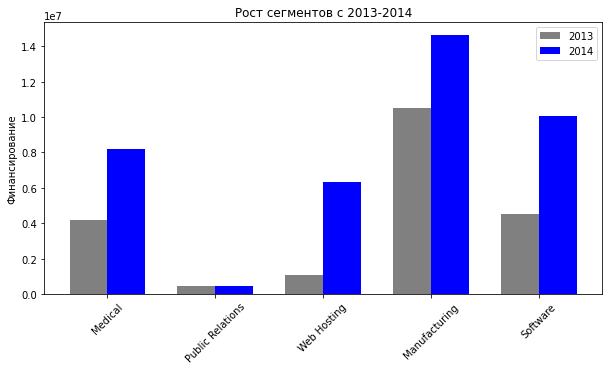

In [40]:
# Рисуем график
segments=['Medical','Public Relations','Web Hosting','Manufacturing','Software']
data_2013=[4180100,426372,1082462,10531434,4500476]
data_2014=[8220780,460000,6319252,14622900,10065000]

plt.figure(figsize=(10,5))
x=range(len(segments))
width=0.35


plt.bar([i-width/2 for i in x],data_2013,width,color='gray',label='2013')
plt.bar([i+width/2 for i in x],data_2014,width,color='blue',label='2014')

plt.xticks(x,segments,rotation=45)
plt.ylabel('Финансирование')
plt.title('Рост сегментов с 2013-2014')
plt.legend()
plt.show()

Web Hosting(483%),Software(124%),Medical(97%) - лидеры с максимальной динамикой за год.

Manufacturing(39%),Public Relations(8%) - показывают умеренный,но уверенный рост



### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

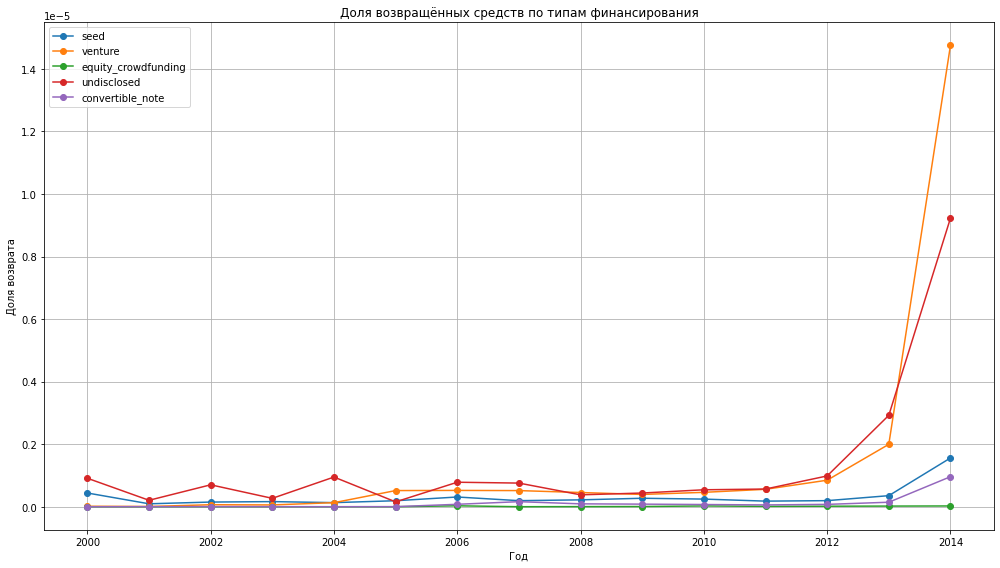

Доля возвратов по годам (первые 5 типов):
      seed  venture  equity_crowdfunding  undisclosed  convertible_note
1785   NaN      NaN                  NaN          NaN               NaN
1802   NaN      NaN                  NaN          NaN               NaN
1817   NaN      NaN                  NaN          NaN               NaN
1826   NaN      NaN                  NaN          NaN               NaN
1831   NaN      NaN                  NaN          NaN               NaN


In [41]:
# Столбцы с типами финансирования:
finans_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                'convertible_note', 'debt_financing', 'angel', 'grant',
                'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                'secondary_market', 'product_crowdfunding']

# Сумма привлеченного финансирования по годам и типам:
finans_by_year = df.groupby('founded_year')[finans_types].sum()

# Сумма возвратов по годам и типам:
return_by_year = df_returns.set_index('year')[finans_types]

# Рассчитаем долю возвратов:
return_ratio = return_by_year / (finans_by_year + 1e-60)

# Убираем аномальные значения:
return_ratio = return_ratio.where((return_ratio >= 0) & (return_ratio <= 1))

# Создаем график динамики:
plt.figure(figsize=(14, 8))
for fund_type in finans_types[:5]:  # правильное имя переменной
    plt.plot(return_ratio.index, return_ratio[fund_type], marker='o', label=fund_type)

plt.title('Доля возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Выводим таблицу
print("Доля возвратов по годам (первые 5 типов):")
print(return_ratio[finans_types[:5]].head().round(3))

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

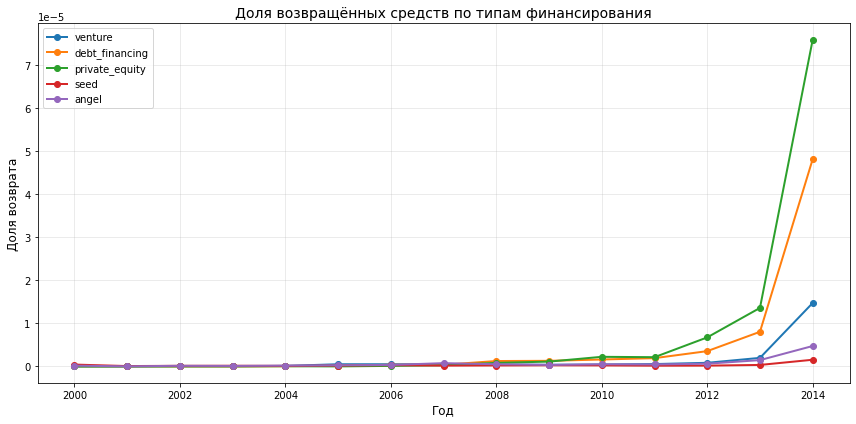

In [42]:
types_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 6))

for fund_type in types_to_plot:
    plt.plot(return_ratio.index, return_ratio[fund_type], 
             marker='o', linewidth=2, label=fund_type)

plt.title('Доля возвращённых средств по типам финансирования', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Самый усточивый рост показателя наблюдается у `debt_financing` и `venture`- это самые надежные типы инвестиций с растущей возвратностью.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Исследовав данные стартапов мы можем сделать следующие выводы:
    - Отрасли в которые стоит инвестировать: Medical(медицина) и Software(софт) - показывают максимальный рост более 95% год и перспективы

-Типы финансирования которые стоит выбрать:
Венчурное(venture) финансирование приносит 85% всех возратов, а сумма долгового финансирования (debt_financing) - показывает устройчивый рост возвратности.

В ходе выполнения проекта были выполнены следущите действия:

1) Произвелди очистку данных: убрали аномалии, оставили компании из городов с 50+ с раундами.

2) Проанализировали типы финансирования. `venture` популярен по объемам, `seed` популярен у стартапов

3) Проанализировали возвраты venture возвращает 85% денег, seed почти не возвращается.

4) Произвели анализ растущих сегментов — Medical, Software, News растут быстрее всех.

5) Анализ возвратности — debt_financing и private_equity показывают устойчивый рост.